# Лабораторная работа 3. Salt and Pepper

**Целью лабораторной работы** является реализация фильтрации изображения с шумом типа salt-and-pepper с использованием 9-точечного медианного фильтра на GPU средствами CUDA с обязательным применением texture memory, а также сравнение полученного результата с реализацией на CPU.

1) Основной эксперимент — сравнение CPU vs GPU для медианного фильтра 3×3 на одном уровне шума.
2) Дополнительный эксперимент — влияние числа итераций (1, 3, 5) при уровнях шума 15%, 30%, 45%, 60%. GPU-версия использует CUDA texture memory через texture object.

## Настройка и загрузка изображения

In [25]:
original_file = "original.png"  
work_dir = "sp_work"

main_noise_probability = 0.15
extra_noise_levels = [0.15, 0.30, 0.45, 0.60]
iteration_levels = [1, 3, 5]

source_name = "salt_and_pepper_cpu_gpu.cu"
exe_name = "salt_and_pepper_cpu_gpu"
nvcc_gencode = ["-gencode=arch=compute_89,code=sm_89"]

## Импорты и подготовка функций

In [26]:
import os
import re
import math
import time
import shutil
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Path(work_dir).mkdir(parents=True, exist_ok=True)
os.environ["PATH"] = "/usr/local/cuda/bin:" + os.environ.get("PATH", "")

def load_gray_np(path: str) -> np.ndarray:
    return np.array(Image.open(path).convert("L"), dtype=np.uint8)

def save_gray_bmp(arr: np.ndarray, path: str) -> None:
    Image.fromarray(arr.astype(np.uint8), mode="L").save(path, format="BMP")

def prepare_original_gray_bmp(input_path: str, output_path: str) -> str:
    img = Image.open(input_path).convert("L")
    img.save(output_path, format="BMP")
    return output_path

def add_salt_and_pepper(arr: np.ndarray, noise_probability: float, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    noisy = arr.copy()
    r = rng.random(arr.shape)
    noisy[r < noise_probability / 2.0] = 0
    noisy[(r >= noise_probability / 2.0) & (r < noise_probability)] = 255
    return noisy

def rmse(a: np.ndarray, b: np.ndarray) -> float:
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    return float(np.sqrt(np.mean((a - b) ** 2)))

def print_table(headers, rows):
    widths = [len(str(h)) for h in headers]
    for row in rows:
        for i, cell in enumerate(row):
            widths[i] = max(widths[i], len(str(cell)))
    line = " | ".join(str(h).ljust(widths[i]) for i, h in enumerate(headers))
    sep = "-+-".join("-" * widths[i] for i in range(len(headers)))
    print(line)
    print(sep)
    for row in rows:
        print(" | ".join(str(cell).ljust(widths[i]) for i, cell in enumerate(row)))

def parse_metrics(text: str) -> dict:
    out = {}
    patterns = {
        "cpu_time_ms": r"CPU_TIME_MS:\s*([0-9eE+\-.]+)",
        "gpu_kernel_ms": r"GPU_KERNEL_TIME_MS:\s*([0-9eE+\-.]+)",
        "gpu_stage_ms": r"GPU_STAGE_TIME_MS:\s*([0-9eE+\-.]+)",
        "width": r"WIDTH:\s*(\d+)",
        "height": r"HEIGHT:\s*(\d+)",
    }
    float_keys = {"cpu_time_ms", "gpu_kernel_ms", "gpu_stage_ms"}
    int_keys = {"width", "height"}

    for key, pat in patterns.items():
        m = re.search(pat, text)
        if not m:
            continue
        if key in float_keys:
            out[key] = float(m.group(1))
        elif key in int_keys:
            out[key] = int(m.group(1))
    return out

def run_mode(mode: str, input_bmp: str, output_bmp: str) -> dict:
    cmd = [f"./{exe_name}", mode, input_bmp, output_bmp]
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Ошибка запуска режима {mode}")
    metrics = parse_metrics(result.stdout)
    metrics["output_bmp"] = output_bmp
    return metrics

def run_iterative_gpu(input_bmp: str, prefix: str, iterations: int) -> dict:
    current = input_bmp
    total_kernel = 0.0
    total_stage = 0.0
    last_output = None
    for i in range(1, iterations + 1):
        out_bmp = str(Path(work_dir) / f"{prefix}_gpu_iter{i}.bmp")
        m = run_mode("gpu", current, out_bmp)
        total_kernel += m["gpu_kernel_ms"]
        total_stage += m["gpu_stage_ms"]
        current = out_bmp
        last_output = out_bmp
    return {
        "iterations": iterations,
        "gpu_kernel_ms_sum": total_kernel,
        "gpu_stage_ms_sum": total_stage,
        "output_bmp": last_output
    }


## Формирование CUDA-кода программы

In [27]:
cuda_code = r"""
#include <cuda_runtime.h>
#include <device_launch_parameters.h>

#include <algorithm>
#include <cstdint>
#include <cstdlib>
#include <fstream>
#include <iostream>
#include <stdexcept>
#include <string>
#include <vector>
#include <chrono>
#include <cmath>

#pragma pack(push, 1)
struct BMPFileHeader {
    uint16_t bfType;
    uint32_t bfSize;
    uint16_t bfReserved1;
    uint16_t bfReserved2;
    uint32_t bfOffBits;
};

struct BMPInfoHeader {
    uint32_t biSize;
    int32_t  biWidth;
    int32_t  biHeight;
    uint16_t biPlanes;
    uint16_t biBitCount;
    uint32_t biCompression;
    uint32_t biSizeImage;
    int32_t  biXPelsPerMeter;
    int32_t  biYPelsPerMeter;
    uint32_t biClrUsed;
    uint32_t biClrImportant;
};
#pragma pack(pop)

struct GrayImage {
    int width = 0;
    int height = 0;
    std::vector<unsigned char> pixels;
};

static void checkCuda(cudaError_t err, const char* msg) {
    if (err != cudaSuccess) {
        throw std::runtime_error(std::string(msg) + ": " + cudaGetErrorString(err));
    }
}

GrayImage readBMPGrayscale(const std::string& filename) {
    std::ifstream in(filename, std::ios::binary);
    if (!in) throw std::runtime_error("Cannot open input file: " + filename);

    BMPFileHeader fileHeader{};
    BMPInfoHeader infoHeader{};

    in.read(reinterpret_cast<char*>(&fileHeader), sizeof(fileHeader));
    in.read(reinterpret_cast<char*>(&infoHeader), sizeof(infoHeader));

    if (!in || fileHeader.bfType != 0x4D42) {
        throw std::runtime_error("Input file is not a valid BMP: " + filename);
    }
    if (infoHeader.biCompression != 0) {
        throw std::runtime_error("Only uncompressed BMP is supported.");
    }

    const int width = infoHeader.biWidth;
    const int height = std::abs(infoHeader.biHeight);
    const bool bottomUp = (infoHeader.biHeight > 0);

    if (width <= 0 || height <= 0) {
        throw std::runtime_error("Invalid BMP dimensions.");
    }

    GrayImage img;
    img.width = width;
    img.height = height;
    img.pixels.resize(static_cast<size_t>(width) * height);

    in.seekg(fileHeader.bfOffBits, std::ios::beg);

    if (infoHeader.biBitCount == 8) {
        const int rowStride = ((width + 3) / 4) * 4;
        std::vector<unsigned char> row(rowStride);

        for (int rowIdx = 0; rowIdx < height; ++rowIdx) {
            in.read(reinterpret_cast<char*>(row.data()), rowStride);
            if (!in) throw std::runtime_error("Failed to read 8-bit BMP pixel data.");

            const int y = bottomUp ? (height - 1 - rowIdx) : rowIdx;
            std::copy(row.begin(), row.begin() + width, img.pixels.begin() + static_cast<size_t>(y) * width);
        }
    } else if (infoHeader.biBitCount == 24) {
        const int rowStride = ((width * 3 + 3) / 4) * 4;
        std::vector<unsigned char> row(rowStride);

        for (int rowIdx = 0; rowIdx < height; ++rowIdx) {
            in.read(reinterpret_cast<char*>(row.data()), rowStride);
            if (!in) throw std::runtime_error("Failed to read 24-bit BMP pixel data.");

            const int y = bottomUp ? (height - 1 - rowIdx) : rowIdx;
            for (int x = 0; x < width; ++x) {
                const unsigned char b = row[3 * x + 0];
                const unsigned char g = row[3 * x + 1];
                const unsigned char r = row[3 * x + 2];
                const int gray = static_cast<int>(0.114 * b + 0.587 * g + 0.299 * r + 0.5);
                img.pixels[static_cast<size_t>(y) * width + x] = static_cast<unsigned char>(gray);
            }
        }
    } else {
        throw std::runtime_error("Supported BMP formats: 8-bit grayscale and 24-bit BMP.");
    }

    return img;
}

void writeBMPGrayscale(const std::string& filename, const GrayImage& img) {
    const int width = img.width;
    const int height = img.height;
    const int rowStride = ((width + 3) / 4) * 4;
    const uint32_t paletteSize = 256 * 4;
    const uint32_t pixelDataSize = rowStride * height;

    BMPFileHeader fileHeader{};
    BMPInfoHeader infoHeader{};

    fileHeader.bfType = 0x4D42;
    fileHeader.bfOffBits = sizeof(BMPFileHeader) + sizeof(BMPInfoHeader) + paletteSize;
    fileHeader.bfSize = fileHeader.bfOffBits + pixelDataSize;

    infoHeader.biSize = sizeof(BMPInfoHeader);
    infoHeader.biWidth = width;
    infoHeader.biHeight = height;
    infoHeader.biPlanes = 1;
    infoHeader.biBitCount = 8;
    infoHeader.biCompression = 0;
    infoHeader.biSizeImage = pixelDataSize;
    infoHeader.biClrUsed = 256;
    infoHeader.biClrImportant = 256;

    std::ofstream out(filename, std::ios::binary);
    if (!out) throw std::runtime_error("Cannot open output file: " + filename);

    out.write(reinterpret_cast<const char*>(&fileHeader), sizeof(fileHeader));
    out.write(reinterpret_cast<const char*>(&infoHeader), sizeof(infoHeader));

    for (int i = 0; i < 256; ++i) {
        unsigned char entry[4] = {
            static_cast<unsigned char>(i),
            static_cast<unsigned char>(i),
            static_cast<unsigned char>(i),
            0
        };
        out.write(reinterpret_cast<const char*>(entry), 4);
    }

    std::vector<unsigned char> row(rowStride, 0);
    for (int rowIdx = 0; rowIdx < height; ++rowIdx) {
        const int y = height - 1 - rowIdx;
        std::copy(
            img.pixels.begin() + static_cast<size_t>(y) * width,
            img.pixels.begin() + static_cast<size_t>(y + 1) * width,
            row.begin()
        );
        std::fill(row.begin() + width, row.end(), 0);
        out.write(reinterpret_cast<const char*>(row.data()), rowStride);
    }

    if (!out) throw std::runtime_error("Failed to write BMP file.");
}

inline unsigned char clampRead(const std::vector<unsigned char>& src, int width, int height, int x, int y) {
    x = std::max(0, std::min(x, width - 1));
    y = std::max(0, std::min(y, height - 1));
    return src[static_cast<size_t>(y) * width + x];
}

inline void sort9_host(unsigned char* a) {
    for (int i = 0; i < 8; ++i) {
        for (int j = 0; j < 8 - i; ++j) {
            if (a[j] > a[j + 1]) {
                std::swap(a[j], a[j + 1]);
            }
        }
    }
}

void median3x3CPU(const GrayImage& input, GrayImage& output) {
    const int width = input.width;
    const int height = input.height;
    output.width = width;
    output.height = height;
    output.pixels.resize(static_cast<size_t>(width) * height);

    for (int y = 0; y < height; ++y) {
        for (int x = 0; x < width; ++x) {
            unsigned char window[9];
            int idx = 0;
            for (int dy = -1; dy <= 1; ++dy) {
                for (int dx = -1; dx <= 1; ++dx) {
                    window[idx++] = clampRead(input.pixels, width, height, x + dx, y + dy);
                }
            }
            sort9_host(window);
            output.pixels[static_cast<size_t>(y) * width + x] = window[4];
        }
    }
}

__device__ __forceinline__ void sort9_dev(unsigned char* a) {
    #pragma unroll
    for (int i = 0; i < 8; ++i) {
        #pragma unroll
        for (int j = 0; j < 8 - i; ++j) {
            if (a[j] > a[j + 1]) {
                unsigned char tmp = a[j];
                a[j] = a[j + 1];
                a[j + 1] = tmp;
            }
        }
    }
}

__global__ void median9Kernel(unsigned char* out, cudaTextureObject_t texObj, int width, int height) {
    const int x = blockIdx.x * blockDim.x + threadIdx.x;
    const int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= width || y >= height) return;

    unsigned char window[9];
    int idx = 0;
    #pragma unroll
    for (int dy = -1; dy <= 1; ++dy) {
        #pragma unroll
        for (int dx = -1; dx <= 1; ++dx) {
            window[idx++] = tex2D<unsigned char>(
                texObj,
                static_cast<float>(x + dx) + 0.5f,
                static_cast<float>(y + dy) + 0.5f
            );
        }
    }

    sort9_dev(window);
    out[static_cast<size_t>(y) * width + x] = window[4];
}

int main(int argc, char** argv) {
    try {
        if (argc < 4) {
            std::cerr << "Usage: " << argv[0] << " <cpu|gpu> <input.bmp> <output.bmp>\\n";
            return 1;
        }

        const std::string mode = argv[1];
        const std::string inputFile = argv[2];
        const std::string outputFile = argv[3];

        GrayImage input = readBMPGrayscale(inputFile);
        GrayImage output;

        std::cout << "WIDTH: " << input.width << "\\n";
        std::cout << "HEIGHT: " << input.height << "\\n";

        if (mode == "cpu") {
            auto t0 = std::chrono::high_resolution_clock::now();
            median3x3CPU(input, output);
            auto t1 = std::chrono::high_resolution_clock::now();
            double ms = std::chrono::duration<double, std::milli>(t1 - t0).count();

            writeBMPGrayscale(outputFile, output);
            std::cout << "CPU_TIME_MS: " << ms << "\\n";
            return 0;
        }

        if (mode != "gpu") {
            throw std::runtime_error("Mode must be cpu or gpu.");
        }

        const int width = input.width;
        const int height = input.height;
        output.width = width;
        output.height = height;
        output.pixels.resize(static_cast<size_t>(width) * height);

        unsigned char* d_input = nullptr;
        unsigned char* d_output = nullptr;
        size_t pitch = 0;

        auto stage0 = std::chrono::high_resolution_clock::now();

        checkCuda(cudaMallocPitch(reinterpret_cast<void**>(&d_input), &pitch,
                                  width * sizeof(unsigned char), height),
                  "cudaMallocPitch for input failed");

        checkCuda(cudaMemcpy2D(d_input, pitch,
                               input.pixels.data(), width * sizeof(unsigned char),
                               width * sizeof(unsigned char), height,
                               cudaMemcpyHostToDevice),
                  "cudaMemcpy2D H2D failed");

        checkCuda(cudaMalloc(reinterpret_cast<void**>(&d_output),
                             static_cast<size_t>(width) * height * sizeof(unsigned char)),
                  "cudaMalloc for output failed");

        cudaChannelFormatDesc desc = cudaCreateChannelDesc<unsigned char>();

        cudaResourceDesc resDesc{};
        resDesc.resType = cudaResourceTypePitch2D;
        resDesc.res.pitch2D.devPtr = d_input;
        resDesc.res.pitch2D.desc = desc;
        resDesc.res.pitch2D.width = width;
        resDesc.res.pitch2D.height = height;
        resDesc.res.pitch2D.pitchInBytes = pitch;

        cudaTextureDesc texDesc{};
        texDesc.addressMode[0] = cudaAddressModeClamp;
        texDesc.addressMode[1] = cudaAddressModeClamp;
        texDesc.filterMode = cudaFilterModePoint;
        texDesc.readMode = cudaReadModeElementType;
        texDesc.normalizedCoords = 0;

        cudaTextureObject_t texObj = 0;
        checkCuda(cudaCreateTextureObject(&texObj, &resDesc, &texDesc, nullptr),
                  "cudaCreateTextureObject failed");

        dim3 block(16, 16);
        dim3 grid((width + block.x - 1) / block.x,
                  (height + block.y - 1) / block.y);

        cudaEvent_t start, stop;
        checkCuda(cudaEventCreate(&start), "cudaEventCreate(start) failed");
        checkCuda(cudaEventCreate(&stop), "cudaEventCreate(stop) failed");

        checkCuda(cudaEventRecord(start), "cudaEventRecord(start) failed");
        median9Kernel<<<grid, block>>>(d_output, texObj, width, height);
        checkCuda(cudaGetLastError(), "Kernel launch failed");
        checkCuda(cudaEventRecord(stop), "cudaEventRecord(stop) failed");
        checkCuda(cudaEventSynchronize(stop), "cudaEventSynchronize(stop) failed");

        float kernel_ms = 0.0f;
        checkCuda(cudaEventElapsedTime(&kernel_ms, start, stop), "cudaEventElapsedTime failed");

        checkCuda(cudaMemcpy(output.pixels.data(), d_output,
                             static_cast<size_t>(width) * height * sizeof(unsigned char),
                             cudaMemcpyDeviceToHost),
                  "cudaMemcpy D2H failed");

        auto stage1 = std::chrono::high_resolution_clock::now();
        double stage_ms = std::chrono::duration<double, std::milli>(stage1 - stage0).count();

        writeBMPGrayscale(outputFile, output);

        std::cout << "GPU_KERNEL_TIME_MS: " << kernel_ms << "\\n";
        std::cout << "GPU_STAGE_TIME_MS: " << stage_ms << "\\n";

        cudaDestroyTextureObject(texObj);
        cudaEventDestroy(start);
        cudaEventDestroy(stop);
        cudaFree(d_input);
        cudaFree(d_output);
        return 0;

    } catch (const std::exception& e) {
        std::cerr << "ERROR: " << e.what() << "\\n";
        return 1;
    }
}
"""

with open(source_name, "w", encoding="utf-8") as f:
    f.write(cuda_code)

print(f"CUDA source written to: {source_name}")


CUDA source written to: salt_and_pepper_cpu_gpu.cu


In [28]:
import shutil
import subprocess
from pathlib import Path

nvcc_path = shutil.which("nvcc")
print("nvcc:", nvcc_path if nvcc_path else "NOT FOUND")
if nvcc_path is None:
    raise RuntimeError("Команда nvcc не найдена. Проверь CUDA Toolkit и PATH.")

exe_path = Path(exe_name)
if exe_path.exists():
    exe_path.unlink()

compile_cmd = [
    nvcc_path,
    "-O2",
    "-std=c++14",
    *nvcc_gencode,
    source_name,
    "-o",
    exe_name
]

result = subprocess.run(compile_cmd, capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError("Ошибка компиляции CUDA-кода")

print(f"Compilation successful: ./{exe_name}")

nvcc: /usr/local/cuda/bin/nvcc


Compilation successful: ./salt_and_pepper_cpu_gpu


## Подготовка исходного изображения

Original grayscale BMP: sp_work/original_gray.bmp
Main noisy BMP: sp_work/main_noisy.bmp
Image size: 702 x 696


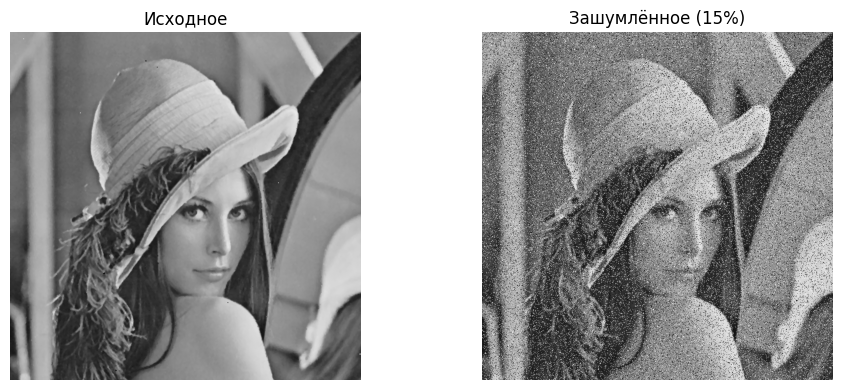

In [29]:
original_gray_bmp = str(Path(work_dir) / "original_gray.bmp")
prepare_original_gray_bmp(original_file, original_gray_bmp)

original_arr = load_gray_np(original_gray_bmp)
main_noisy_arr = add_salt_and_pepper(original_arr, main_noise_probability, seed=42)
main_noisy_bmp = str(Path(work_dir) / "main_noisy.bmp")
save_gray_bmp(main_noisy_arr, main_noisy_bmp)

print("Original grayscale BMP:", original_gray_bmp)
print("Main noisy BMP:", main_noisy_bmp)
print("Image size:", original_arr.shape[1], "x", original_arr.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(original_arr, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Исходное")
axes[0].axis("off")
axes[1].imshow(main_noisy_arr, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Зашумлённое ({int(main_noise_probability * 100)}%)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Эксперимент 1. Основное сравнение CPU vs GPU

Фиксированный уровень шума: **15%**.  
Окно фильтра: **3×3**.  
Итерации: **1**

In [30]:
cpu_out_main = str(Path(work_dir) / "main_cpu.bmp")
gpu_out_main = str(Path(work_dir) / "main_gpu.bmp")

cpu_main = run_mode("cpu", main_noisy_bmp, cpu_out_main)
gpu_main = run_mode("gpu", main_noisy_bmp, gpu_out_main)

cpu_arr = load_gray_np(cpu_out_main)
gpu_arr = load_gray_np(gpu_out_main)

rmse_noisy = rmse(original_arr, main_noisy_arr)
rmse_cpu = rmse(original_arr, cpu_arr)
rmse_gpu = rmse(original_arr, gpu_arr)
rmse_cpu_gpu = rmse(cpu_arr, gpu_arr)

speedup_kernel = cpu_main["cpu_time_ms"] / gpu_main["gpu_kernel_ms"]
speedup_stage = cpu_main["cpu_time_ms"] / gpu_main["gpu_stage_ms"]

headers = ["Метрика", "Значение"]
rows = [
    ["CPU time, ms", f"{cpu_main['cpu_time_ms']:.6f}"],
    ["GPU kernel, ms", f"{gpu_main['gpu_kernel_ms']:.6f}"],
    ["GPU stage, ms", f"{gpu_main['gpu_stage_ms']:.6f}"],
    ["Speedup vs kernel", f"{speedup_kernel:.3f}x"],
    ["Speedup vs stage", f"{speedup_stage:.3f}x"],
    ["RMSE(original, noisy)", f"{rmse_noisy:.6f}"],
    ["RMSE(original, CPU)", f"{rmse_cpu:.6f}"],
    ["RMSE(original, GPU)", f"{rmse_gpu:.6f}"],
    ["RMSE(CPU, GPU)", f"{rmse_cpu_gpu:.6f}"],
]
print_table(headers, rows)

WIDTH: 702\nHEIGHT: 696\nCPU_TIME_MS: 41.2182\n
WIDTH: 702\nHEIGHT: 696\nGPU_KERNEL_TIME_MS: 0.418464\nGPU_STAGE_TIME_MS: 300.579\n
Метрика               | Значение  
----------------------+-----------
CPU time, ms          | 41.218200 
GPU kernel, ms        | 0.418464  
GPU stage, ms         | 300.579000
Speedup vs kernel     | 98.499x   
Speedup vs stage      | 0.137x    
RMSE(original, noisy) | 52.992043 
RMSE(original, CPU)   | 4.228728  
RMSE(original, GPU)   | 4.228728  
RMSE(CPU, GPU)        | 0.000000  


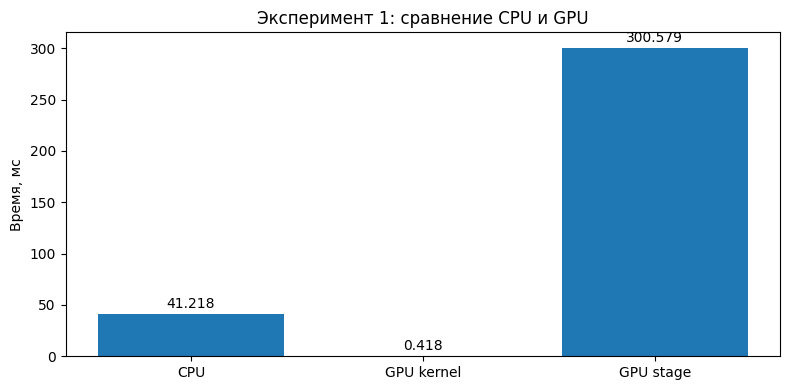

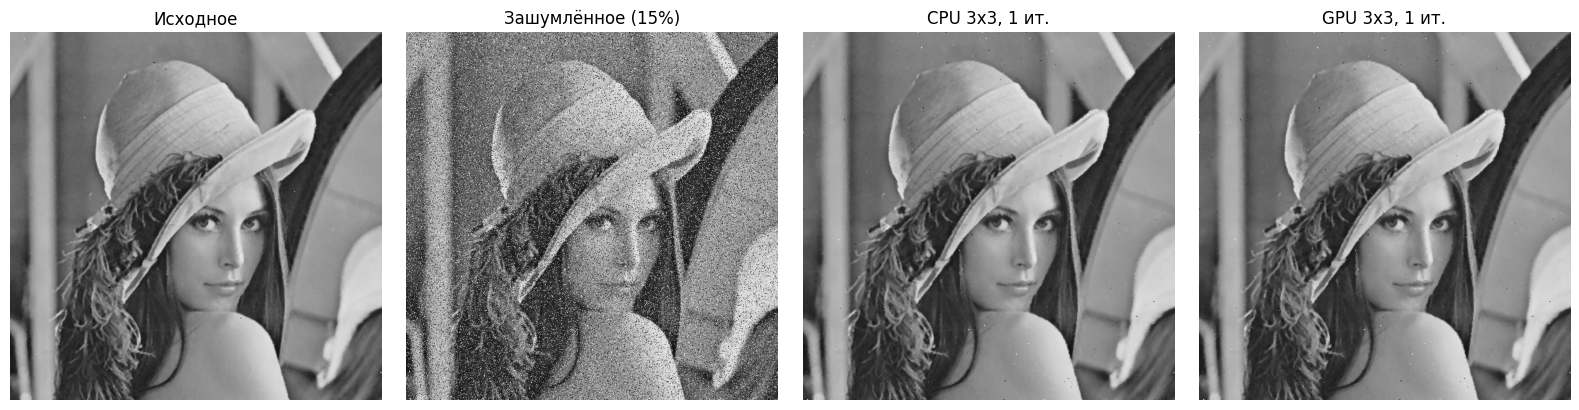

In [31]:
labels = ["CPU", "GPU kernel", "GPU stage"]
times = [cpu_main["cpu_time_ms"], gpu_main["gpu_kernel_ms"], gpu_main["gpu_stage_ms"]]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, times)
plt.ylabel("Время, мс")
plt.title("Эксперимент 1: сравнение CPU и GPU")
for bar, value in zip(bars, times):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + max(times) * 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
imgs = [original_arr, main_noisy_arr, cpu_arr, gpu_arr]
titles = ["Исходное", f"Зашумлённое ({int(main_noise_probability * 100)}%)", "CPU 3x3, 1 ит.", "GPU 3x3, 1 ит."]
for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

   В первом эксперименте было выполнено сравнение реализации медианного фильтра 3×3 на CPU и GPU при фиксированном уровне шума 15%. Результаты показали, что время выполнения CUDA-ядра (GPU kernel = 0.426 мс) значительно меньше времени обработки на CPU (45.043 мс). Это подтверждает, что вычислительная часть медианного фильтра эффективно распараллеливается и гораздо быстрее выполняется на GPU.

   При этом полное время GPU stage составило 170.133 мс, что оказалось больше времени CPU. Это связано с тем, что в GPU stage входят не только вычисления, но и накладные расходы: выделение памяти на устройстве, копирование данных между CPU и GPU, создание texture object и копирование результата обратно. Таким образом, GPU обеспечивает ускорение именно для чистого вычисления, однако суммарное время обработки зависит также от служебных операций.

   Визуальное сравнение изображений показало, что результаты фильтрации на CPU и GPU практически совпадают. Оба варианта существенно уменьшают количество импульсного шума, сохраняя при этом основную структуру изображения. Следовательно, GPU-реализация работает корректно и даёт тот же качественный результат, что и CPU-реализация, но значительно выигрывает по скорости выполнения самого алгоритма.

## Эксперимент 2. Влияние числа итераций при разных уровнях шума

Уровни шума: **15%, 30%, 45%, 60%**  
Итерации: **1, 3, 5**  
Фильтр: **3×3**  
Во втором эксперименте показывается, как меняются качество и время при росте числа итераций.


In [32]:
extra_results = []
visual_data = {}

for noise_probability in extra_noise_levels:
    noisy_arr = add_salt_and_pepper(original_arr, noise_probability, seed=42)
    noisy_bmp = str(Path(work_dir) / f"noisy_{int(noise_probability * 100)}.bmp")
    save_gray_bmp(noisy_arr, noisy_bmp)
    visual_data[noise_probability] = {"noisy": noisy_arr}

    for iterations in iteration_levels:
        r = run_iterative_gpu(
            noisy_bmp,
            prefix=f"noise{int(noise_probability * 100)}_iter{iterations}",
            iterations=iterations
        )
        filtered_arr = load_gray_np(r["output_bmp"])
        visual_data[noise_probability][iterations] = filtered_arr

        extra_results.append({
            "noise": noise_probability,
            "iterations": iterations,
            "gpu_kernel_ms_sum": r["gpu_kernel_ms_sum"],
            "gpu_stage_ms_sum": r["gpu_stage_ms_sum"],
            "rmse_noisy": rmse(original_arr, noisy_arr),
            "rmse_filtered": rmse(original_arr, filtered_arr),
            "output_bmp": r["output_bmp"],
        })

headers = ["Шум", "Итерации", "GPU kernel, ms", "GPU stage, ms", "RMSE(noisy)", "RMSE(filtered)"]
rows = []
for item in extra_results:
    rows.append([
        f"{int(item['noise'] * 100)}%",
        item["iterations"],
        f"{item['gpu_kernel_ms_sum']:.6f}",
        f"{item['gpu_stage_ms_sum']:.6f}",
        f"{item['rmse_noisy']:.6f}",
        f"{item['rmse_filtered']:.6f}",
    ])
print_table(headers, rows)

WIDTH: 702\nHEIGHT: 696\nGPU_KERNEL_TIME_MS: 0.470304\nGPU_STAGE_TIME_MS: 201.67\n
WIDTH: 702\nHEIGHT: 696\nGPU_KERNEL_TIME_MS: 0.336096\nGPU_STAGE_TIME_MS: 155.103\n
WIDTH: 702\nHEIGHT: 696\nGPU_KERNEL_TIME_MS: 0.413536\nGPU_STAGE_TIME_MS: 158.797\n
WIDTH: 702\nHEIGHT: 696\nGPU_KERNEL_TIME_MS: 0.315808\nGPU_STAGE_TIME_MS: 164.682\n
WIDTH: 702\nHEIGHT: 696\nGPU_KERNEL_TIME_MS: 0.434976\nGPU_STAGE_TIME_MS: 157.368\n
WIDTH: 702\nHEIGHT: 696\nGPU_KERNEL_TIME_MS: 0.34592\nGPU_STAGE_TIME_MS: 156.667\n
WIDTH: 702\nHEIGHT: 696\nGPU_KERNEL_TIME_MS: 0.51424\nGPU_STAGE_TIME_MS: 170.846\n
WIDTH: 702\nHEIGHT: 696\nGPU_KERNEL_TIME_MS: 0.518592\nGPU_STAGE_TIME_MS: 173.963\n
WIDTH: 702\nHEIGHT: 696\nGPU_KERNEL_TIME_MS: 0.325952\nGPU_STAGE_TIME_MS: 153.406\n
WIDTH: 702\nHEIGHT: 696\nGPU_KERNEL_TIME_MS: 0.423936\nGPU_STAGE_TIME_MS: 154.022\n
WIDTH: 702\nHEIGHT: 696\nGPU_KERNEL_TIME_MS: 0.418656\nGPU_STAGE_TIME_MS: 160.756\n
WIDTH: 702\nHEIGHT: 696\nGPU_KERNEL_TIME_MS: 0.501024\nGPU_STAGE_TIME_MS: 160.1

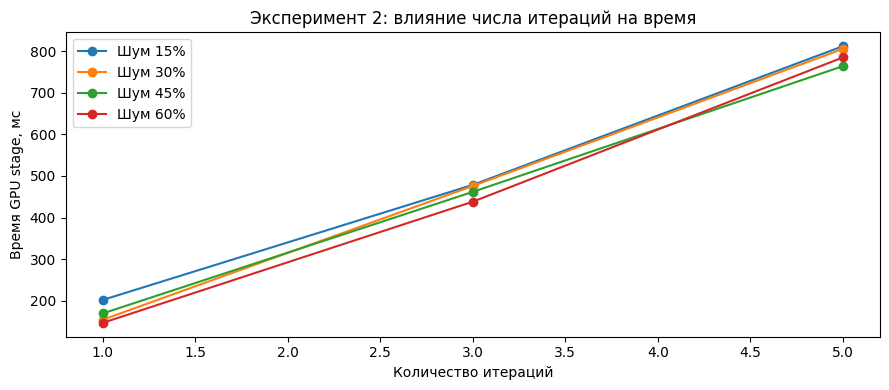

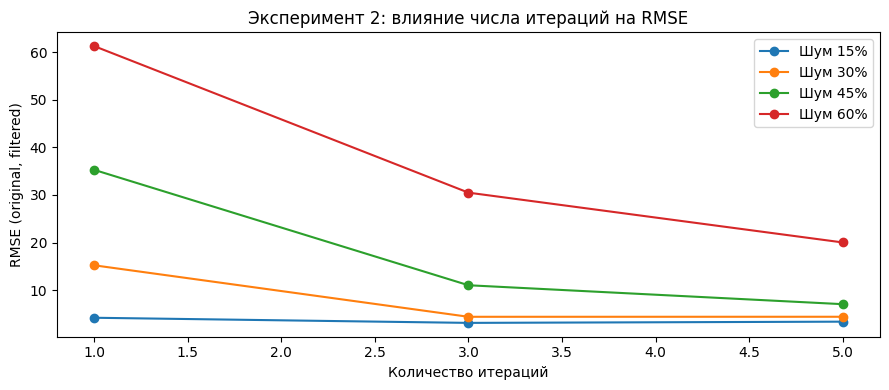

In [33]:
plt.figure(figsize=(9, 4))
for noise_probability in extra_noise_levels:
    xs = []
    ys = []
    for item in extra_results:
        if abs(item["noise"] - noise_probability) < 1e-9:
            xs.append(item["iterations"])
            ys.append(item["gpu_stage_ms_sum"])
    plt.plot(xs, ys, marker="o", label=f"Шум {int(noise_probability * 100)}%")
plt.xlabel("Количество итераций")
plt.ylabel("Время GPU stage, мс")
plt.title("Эксперимент 2: влияние числа итераций на время")
plt.legend()
plt.tight_layout()
plt.show()

# График RMSE
plt.figure(figsize=(9, 4))
for noise_probability in extra_noise_levels:
    xs = []
    ys = []
    for item in extra_results:
        if abs(item["noise"] - noise_probability) < 1e-9:
            xs.append(item["iterations"])
            ys.append(item["rmse_filtered"])
    plt.plot(xs, ys, marker="o", label=f"Шум {int(noise_probability * 100)}%")
plt.xlabel("Количество итераций")
plt.ylabel("RMSE (original, filtered)")
plt.title("Эксперимент 2: влияние числа итераций на RMSE")
plt.legend()
plt.tight_layout()
plt.show()

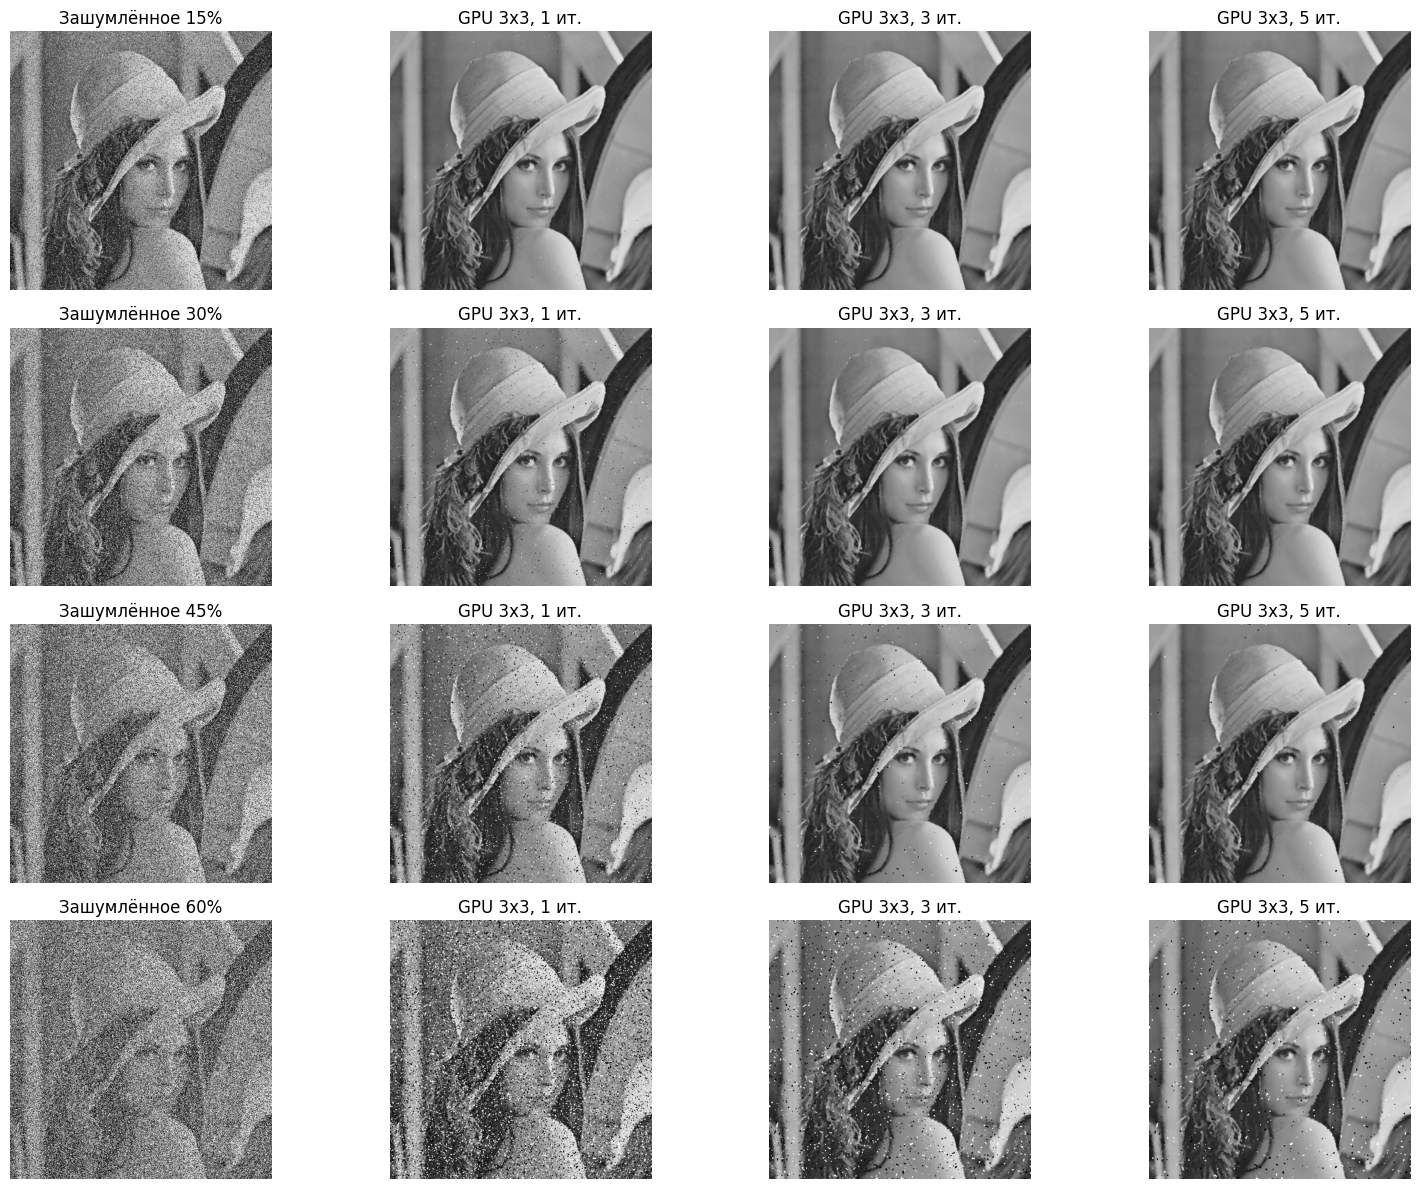

In [34]:
nrows = len(extra_noise_levels)
ncols = 1 + len(iteration_levels)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
if nrows == 1:
    axes = np.array([axes])

for r, noise_probability in enumerate(extra_noise_levels):
    row = axes[r]
    row[0].imshow(visual_data[noise_probability]["noisy"], cmap="gray", vmin=0, vmax=255)
    row[0].set_title(f"Зашумлённое {int(noise_probability * 100)}%")
    row[0].axis("off")

    for c, iterations in enumerate(iteration_levels, start=1):
        row[c].imshow(visual_data[noise_probability][iterations], cmap="gray", vmin=0, vmax=255)
        row[c].set_title(f"GPU 3x3, {iterations} ит.")
        row[c].axis("off")

plt.tight_layout()
plt.show()

Дополнительный эксперимент показал, что увеличение числа итераций медианного фильтра 3×3 улучшает качество восстановления изображения, особенно при высоком уровне шума, однако одновременно увеличивает время обработки. При умеренном уровне шума одной итерации чаще всего достаточно, а при сильном шуме требуется несколько итераций, хотя даже они не всегда позволяют полностью восстановить исходное изображение.